## 📌 Polynomial Regression using Pipeline

Polynomial Regression can be efficiently implemented using a **Pipeline**, which helps automate preprocessing and model training in a clean and reusable way.

---

### 🔧 What is a Pipeline?

A Pipeline is a sequence of data processing steps where:
- Input data passes through multiple transformations
- Final step is a machine learning model

---

### ⚙️ Pipeline for Polynomial Regression

In Polynomial Regression, a typical pipeline includes:

1. Polynomial feature transformation  
2. Feature scaling (optional but recommended)  
3. Linear Regression model  

---

### 📐 Mathematical Idea

Polynomial Regression models the relationship as:

Y = β₀ + β₁X + β₂X² + β₃X³ + ... + βₙXⁿ + ε

Where:
- n = degree of the polynomial  
- Higher degree → more complex curve  

---

### 🧠 General Pipeline Structure

- Step 1: Convert X → polynomial features up to degree n  
- Step 2: Scale features (for better performance)  
- Step 3: Apply Linear Regression  

---

### 📊 Advantages of Using Pipeline

- Cleaner and more readable code  
- Prevents data leakage  
- Ensures same transformation on train and test data  
- Easy to reuse and tune  

---

### ⚠️ Important Notes

- Always choose degree carefully  
- High degree may cause overfitting  
- Use cross-validation to select best degree  

---

### 🧪 Example Workflow

1. Define pipeline with degree = n  
2. Fit model on training data  
3. Predict on test data  
4. Evaluate performance  

---

### 🧠 Tip

Pipeline ensures that all transformations are applied consistently, making your model more reliable and production-ready.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def poly_regression_pipeline(degree, X_train, y_train, X_test, y_test):
    
    # Generate smooth line points
    X_new = np.linspace(min(X_train), max(X_train), 200).reshape(200, 1)

    # Create pipeline
    poly_regression = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin_reg', LinearRegression())
    ])

    # Train model
    poly_regression.fit(X_train, y_train)

    # Predictions
    y_train_pred = poly_regression.predict(X_train)
    y_test_pred = poly_regression.predict(X_test)
    y_pred_new = poly_regression.predict(X_new)

    # =========================
    # 📊 Performance Metrics
    # =========================
    print(f"\n📌 Degree {degree} Performance:")

    print("---- TRAIN ----")
    print("MSE:", mean_squared_error(y_train, y_train_pred))
    print("MAE:", mean_absolute_error(y_train, y_train_pred))
    print("R2 Score:", r2_score(y_train, y_train_pred))

    print("---- TEST ----")
    print("MSE:", mean_squared_error(y_test, y_test_pred))
    print("MAE:", mean_absolute_error(y_test, y_test_pred))
    print("R2 Score:", r2_score(y_test, y_test_pred))

    # =========================
    # 📈 Plot
    # =========================
    plt.figure(figsize=(8,5))
    plt.plot(X_new, y_pred_new, 'b', linewidth=2, label=f'Degree {degree}')
    
    plt.scatter(X_train, y_train, color='red', label='Training data')
    plt.scatter(X_test, y_test, color='green', label='Testing data')

    plt.legend()
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.grid(True)
    plt.show()


📌 Degree 3 Performance:
---- TRAIN ----
MSE: 0.9916851308433469
MAE: 0.7810966355788549
R2 Score: 0.8744262317827403
---- TEST ----
MSE: 1.0712478213757135
MAE: 0.8958114873290708
R2 Score: 0.6797908006816251


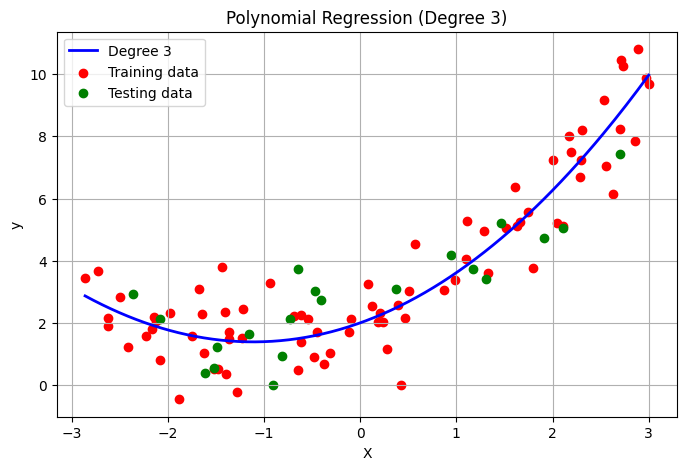

In [20]:
from sklearn.model_selection import train_test_split

# Example dummy data
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Call function
poly_regression_pipeline(3, X_train, y_train, X_test, y_test)